# NancyBot - Phase 1: Data Collection

**Objective**: Collect and prepare Nancy Pelosi's congressional trading data and corresponding stock price data.

**Date**: 2026-03-05

---

## Overview

This notebook handles:
1. Loading congressional trade data (currently using sample data)
2. Downloading historical stock price data
3. Data cleaning and validation
4. Calculating basic metrics (price changes during delay period)
5. Saving processed data for analysis

## Data Sources

**Note**: This implementation uses sample data based on publicly known trades. For production use, integrate with:
- Capitol Trades (capitoltrades.com)
- House Stock Watcher (housestockwatcher.com)
- QuiverQuant API (paid)
- Official House Ethics Disclosures

## Setup

In [1]:
# Standard imports
import sys
print("Imported sys")
import pandas as pd
print("Imported pandas")
import numpy as np
print("Imported numpy")
import matplotlib.pyplot as plt
print("Imported matplotlib")
import seaborn as sns
print("Imported seaborn")
from datetime import datetime, timedelta
print("Imported datetime")
import warnings
print("Imported warnings")
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append('../src')

# Import custom modules
from data_loader import CongressionalTradeLoader, get_next_market_open, calculate_forward_returns
print("Imported custom modules")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Display settings configured!")
# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Setup complete!")

Imported sys
Imported pandas
Imported numpy
Imported matplotlib
Imported seaborn
Imported datetime
Imported warnings
Imported custom modules
Display settings configured!
Setup complete!


## 1. Load Congressional Trade Data

In [2]:
# Initialize loader
loader = CongressionalTradeLoader()

# Create sample data (replace with actual data source in production)
print("Creating sample Nancy Pelosi trade data...")
trade_data = loader.create_sample_data(
    politician="Nancy Pelosi",
    start_date="2020-01-01",
    end_date="2026-03-01"
)

print(f"\nLoaded {len(trade_data)} trades")
print(f"Date range: {trade_data['trade_date'].min()} to {trade_data['trade_date'].max()}")
print(f"\nFirst 5 trades:")
trade_data.head()

Creating sample Nancy Pelosi trade data...

Loaded 20 trades
Date range: 2020-01-15 00:00:00 to 2026-01-27 00:00:00

First 5 trades:


,trade_id,trade_date,disclosure_date,filing_date,delay_days,ticker,transaction_type,amount_range,amount_min,amount_max,amount_midpoint,asset_type,owner,representative,party,state
0,TRADE_000000,2020-01-15,2020-02-22,2020-02-22,38,AAPL,Purchase,"$500,000 - $1,000,000",500000,1000000,750000.0,Stock,Spouse,Nancy Pelosi,Democrat,California
1,TRADE_000001,2020-03-20,2020-04-25,2020-04-25,36,MSFT,Purchase,"$1,000,000 - $5,000,000",1000000,5000000,3000000.0,Stock,Spouse,Nancy Pelosi,Democrat,California
2,TRADE_000002,2020-06-15,2020-07-30,2020-07-30,45,NVDA,Purchase,"$250,000 - $500,000",250000,500000,375000.0,Stock,Spouse,Nancy Pelosi,Democrat,California
3,TRADE_000003,2021-01-21,2021-03-01,2021-03-01,39,TSLA,Purchase,"$500,000 - $1,000,000",500000,1000000,750000.0,Stock,Spouse,Nancy Pelosi,Democrat,California
4,TRADE_000004,2021-03-19,2021-05-02,2021-05-02,44,GOOGL,Purchase,"$1,000,000 - $5,000,000",1000000,5000000,3000000.0,Stock,Spouse,Nancy Pelosi,Democrat,California


In [3]:
# Display trade summary statistics
print("=" * 80)
print("TRADE DATA SUMMARY")
print("=" * 80)
print(f"\nTotal Trades: {len(trade_data)}")
print(f"\nTransaction Types:")
print(trade_data['transaction_type'].value_counts())
print(f"\nUnique Tickers: {trade_data['ticker'].nunique()}")
print(trade_data['ticker'].value_counts())
print(f"\nAverage Delay (days): {trade_data['delay_days'].mean():.1f}")
print(f"Min Delay: {trade_data['delay_days'].min()} days")
print(f"Max Delay: {trade_data['delay_days'].max()} days")
print(f"\nTotal Amount (midpoint estimate): ${trade_data['amount_midpoint'].sum():,.0f}")
print(f"Average Trade Size: ${trade_data['amount_midpoint'].mean():,.0f}")

TRADE DATA SUMMARY

Total Trades: 20

Transaction Types:
transaction_type
Purchase    18
Sale         2
Name: count, dtype: int64

Unique Tickers: 5
ticker
NVDA     9
MSFT     3
TSLA     3
GOOGL    3
AAPL     2
Name: count, dtype: int64

Average Delay (days): 38.5
Min Delay: 30 days
Max Delay: 45 days

Total Amount (midpoint estimate): $51,000,000
Average Trade Size: $2,550,000


## 2. Download Stock Price Data

In [4]:
# Get unique tickers
tickers = loader.get_unique_tickers()
print(f"Tickers to download: {tickers}")

# Determine date range (add buffer before/after)
start_date, end_date = loader.get_date_range()
start_date = start_date - timedelta(days=90)  # 3 months before first trade
end_date = datetime.now()  # Current date

print(f"\nPrice data date range: {start_date.date()} to {end_date.date()}")

# Download price data using batch mode (recommended to avoid rate limits)
# Batch mode downloads all tickers in one request - much better than sequential!
price_data = loader.load_price_data(
    tickers=tickers,
    start_date=start_date.strftime('%Y-%m-%d'),
    end_date=end_date.strftime('%Y-%m-%d'),
    batch_mode=True,  # Default: downloads all at once (recommended)
    delay=3.0,         # Delay for individual fallback mode if needed
    max_retries=3      # Retry with exponential backoff if rate limited
)

Tickers to download: ['AAPL', 'GOOGL', 'MSFT', 'NVDA', 'TSLA']

Price data date range: 2019-10-17 to 2026-03-05
Using batch mode (recommended to avoid rate limits)...
YF.download() has changed argument auto_adjust default to True
  ✓ AAPL (1602 days)
  ✓ GOOGL (1602 days)
  ✓ MSFT (1602 days)
  ✓ NVDA (1602 days)
  ✓ TSLA (1602 days)

Batch download complete: 5/5 tickers

Successfully loaded 5/5 tickers


In [5]:
# Display price data summary
print("=" * 80)
print("PRICE DATA SUMMARY")
print("=" * 80)
for ticker, df in price_data.items():
    print(f"\n{ticker}:")
    print(f"  Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"  Trading days: {len(df)}")
    print(f"  Price range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
    print(f"  Current price: ${df['Close'].iloc[-1]:.2f}")

PRICE DATA SUMMARY

AAPL:
  Date range: 2019-10-17 to 2026-03-04
  Trading days: 1602
  Price range: $54.21 - $285.92
  Current price: $262.52

GOOGL:
  Date range: 2019-10-17 to 2026-03-04
  Trading days: 1602
  Price range: $52.31 - $343.69
  Current price: $303.13

MSFT:
  Date range: 2019-10-17 to 2026-03-04
  Trading days: 1602
  Price range: $128.64 - $539.83
  Current price: $405.20

NVDA:
  Date range: 2019-10-17 to 2026-03-04
  Trading days: 1602
  Price range: $4.74 - $207.03
  Current price: $183.04

TSLA:
  Date range: 2019-10-17 to 2026-03-04
  Trading days: 1602
  Price range: $16.90 - $489.88
  Current price: $405.94


## 3. Calculate Trade Metrics

In [6]:
# Calculate metrics for each trade
print("Calculating trade metrics...")
trade_data_enhanced = loader.calculate_trade_metrics()

print("\nSample of enhanced trade data:")
trade_data_enhanced[[
    'trade_date', 'disclosure_date', 'ticker', 'transaction_type',
    'trade_price', 'disclosure_price', 'price_change_pct_delay', 'delay_days'
]].head(10)

Calculating trade metrics...

Sample of enhanced trade data:


,trade_date,disclosure_date,ticker,transaction_type,trade_price,disclosure_price,price_change_pct_delay,delay_days
0,2020-01-15,2020-02-22,AAPL,Purchase,75.049683,72.048004,-3.999588,38
1,2020-03-20,2020-04-25,MSFT,Purchase,130.469696,165.331284,26.720065,36
2,2020-06-15,2020-07-30,NVDA,Purchase,9.142588,10.577946,15.699691,45
3,2021-01-21,2021-03-01,TSLA,Purchase,281.663330,239.476669,-14.977690,39
4,2021-03-19,2021-05-02,GOOGL,Purchase,100.587990,116.275452,15.595760,44
5,2021-06-18,2021-07-22,NVDA,Purchase,18.597162,19.550274,5.125038,34
6,2021-11-22,2022-01-01,NVDA,Sale,31.890310,30.062765,-5.730722,40
7,2022-01-18,2022-02-28,MSFT,Purchase,292.172058,289.042236,-1.071226,41
8,2022-07-26,2022-08-26,NVDA,Purchase,16.507336,16.234760,-1.651238,31
9,2022-12-28,2023-02-04,TSLA,Sale,112.709999,194.759995,72.797441,38


In [7]:
# Analyze price movement during delay period
purchases = trade_data_enhanced[trade_data_enhanced['transaction_type'] == 'Purchase'].copy()

print("=" * 80)
print("PRICE MOVEMENT DURING DELAY PERIOD (Purchases Only)")
print("=" * 80)
print(f"\nAverage price change: {purchases['price_change_pct_delay'].mean():.2f}%")
print(f"Median price change: {purchases['price_change_pct_delay'].median():.2f}%")
print(f"Std deviation: {purchases['price_change_pct_delay'].std():.2f}%")
print(f"\nPositive changes: {(purchases['price_change_pct_delay'] > 0).sum()} / {len(purchases)}")
print(f"Negative changes: {(purchases['price_change_pct_delay'] < 0).sum()} / {len(purchases)}")

# Distribution
print("\nDistribution:")
print(purchases['price_change_pct_delay'].describe())

PRICE MOVEMENT DURING DELAY PERIOD (Purchases Only)

Average price change: 4.56%
Median price change: 1.18%
Std deviation: 15.64%

Positive changes: 10 / 18
Negative changes: 8 / 18

Distribution:
count    18.000000
mean      4.555591
std      15.644003
min     -27.259138
25%      -3.412501
50%       1.177807
75%      13.438115
max      35.413961
Name: price_change_pct_delay, dtype: float64


## 4. Visualizations

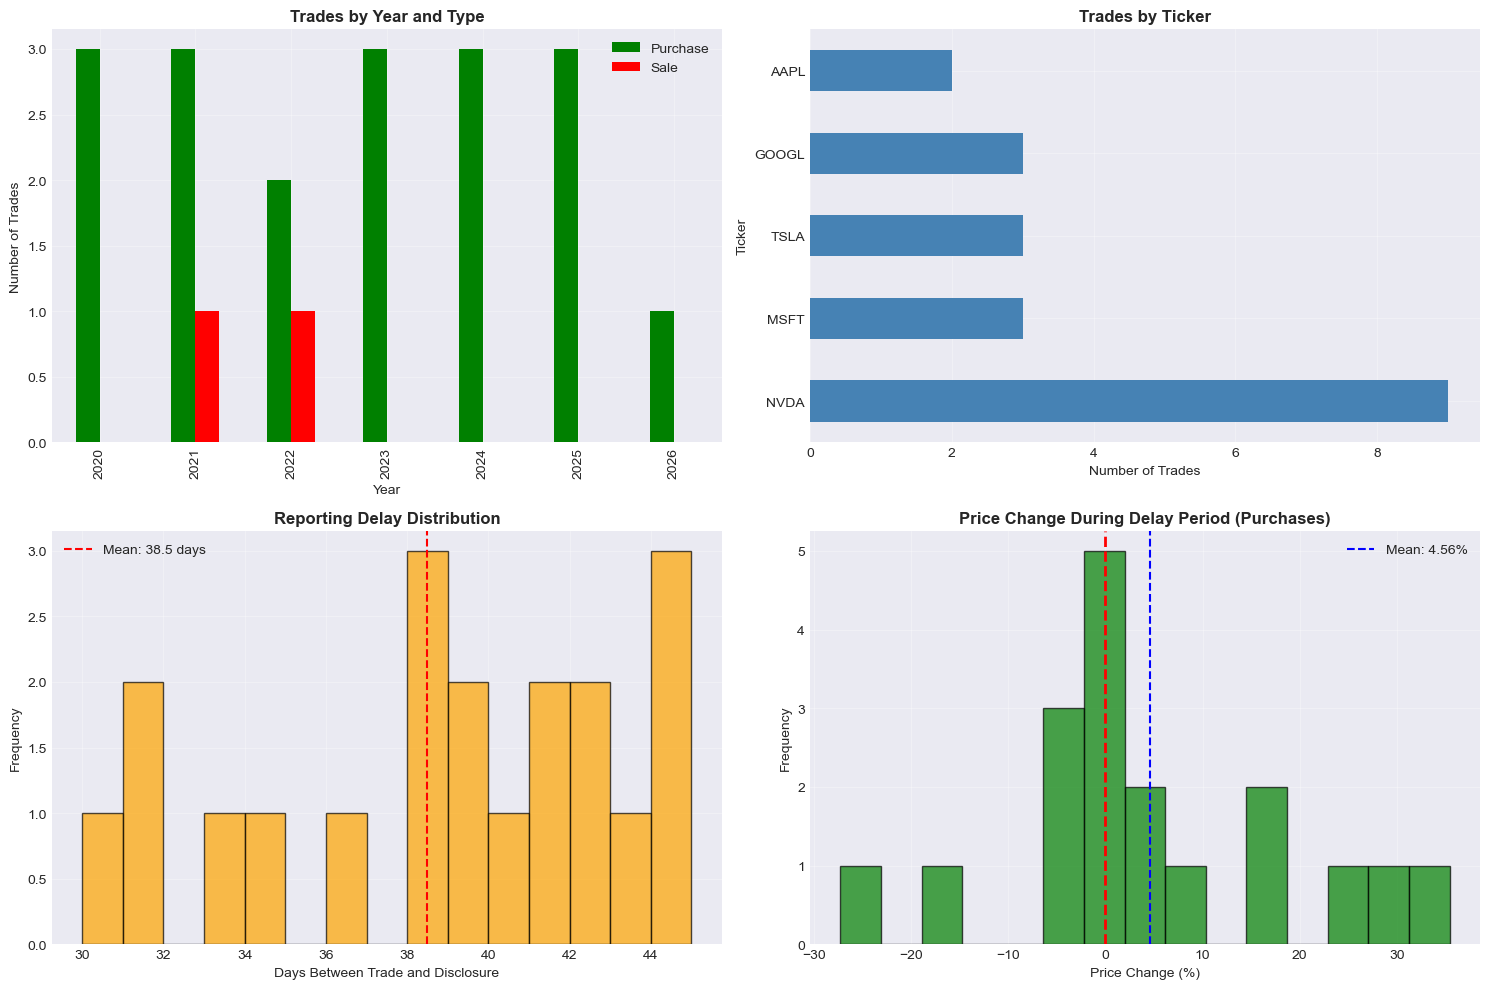

In [8]:
# Plot 1: Trade frequency over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Subplot 1: Trades by year
trade_data_enhanced['year'] = trade_data_enhanced['trade_date'].dt.year
trade_counts = trade_data_enhanced.groupby(['year', 'transaction_type']).size().unstack(fill_value=0)
trade_counts.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Trades by Year and Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Trades')
axes[0, 0].legend(['Purchase', 'Sale'])
axes[0, 0].grid(alpha=0.3)

# Subplot 2: Trades by ticker
ticker_counts = trade_data_enhanced['ticker'].value_counts()
ticker_counts.plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Trades by Ticker', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Trades')
axes[0, 1].set_ylabel('Ticker')
axes[0, 1].grid(alpha=0.3)

# Subplot 3: Reporting delay distribution
axes[1, 0].hist(trade_data_enhanced['delay_days'], bins=15, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Reporting Delay Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Days Between Trade and Disclosure')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(trade_data_enhanced['delay_days'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {trade_data_enhanced['delay_days'].mean():.1f} days")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Subplot 4: Price change during delay (purchases only)
purchases_clean = purchases.dropna(subset=['price_change_pct_delay'])
axes[1, 1].hist(purchases_clean['price_change_pct_delay'], bins=15, 
                color='green', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Price Change During Delay Period (Purchases)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price Change (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(purchases_clean['price_change_pct_delay'].mean(), 
                   color='blue', linestyle='--', 
                   label=f"Mean: {purchases_clean['price_change_pct_delay'].mean():.2f}%")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

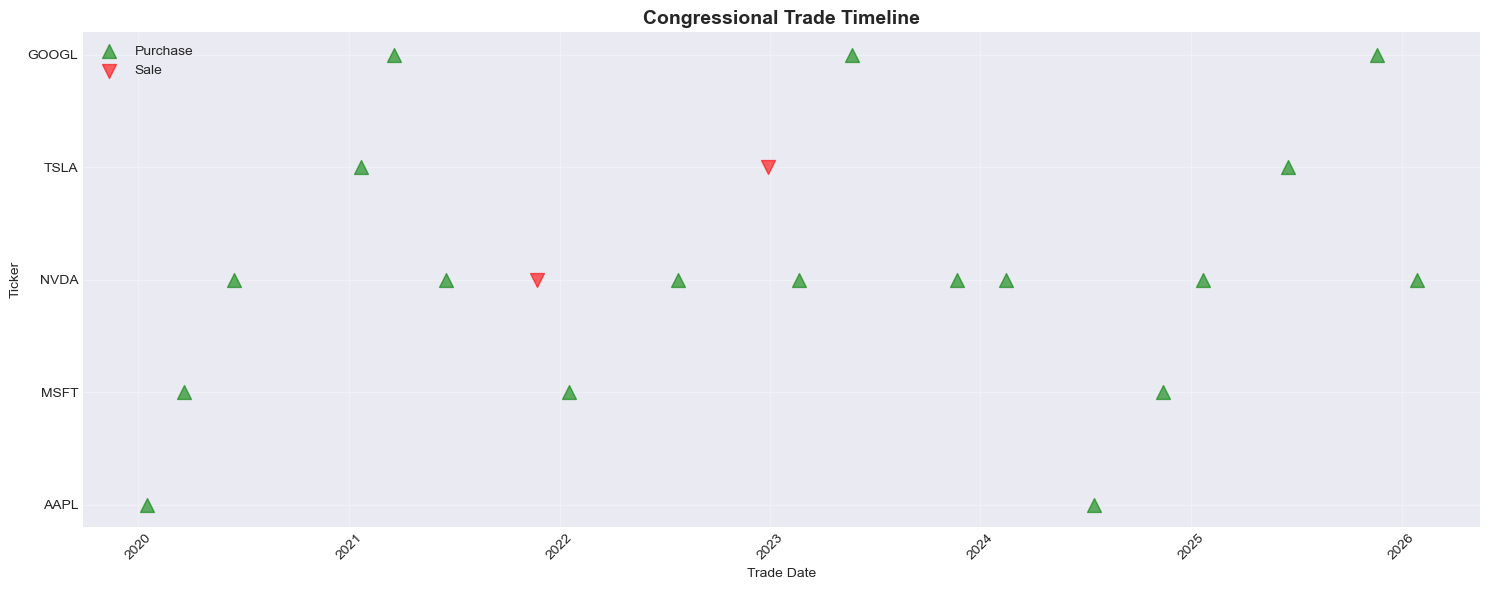

In [9]:
# Plot 2: Trade timeline
fig, ax = plt.subplots(figsize=(15, 6))

purchases_plot = trade_data_enhanced[trade_data_enhanced['transaction_type'] == 'Purchase']
sales_plot = trade_data_enhanced[trade_data_enhanced['transaction_type'] == 'Sale']

ax.scatter(purchases_plot['trade_date'], purchases_plot['ticker'], 
           c='green', marker='^', s=100, alpha=0.6, label='Purchase')
ax.scatter(sales_plot['trade_date'], sales_plot['ticker'], 
           c='red', marker='v', s=100, alpha=0.6, label='Sale')

ax.set_title('Congressional Trade Timeline', fontsize=14, fontweight='bold')
ax.set_xlabel('Trade Date')
ax.set_ylabel('Ticker')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Calculate Forward Returns

In [10]:
# Calculate forward returns from disclosure date
forward_periods = [1, 5, 20, 60]

print("Calculating forward returns from disclosure date...")

for period in forward_periods:
    purchases[f'forward_return_{period}d'] = np.nan

for idx, trade in purchases.iterrows():
    ticker = trade['ticker']
    disclosure_date = trade['disclosure_date']
    
    if ticker in price_data:
        forward_rets = calculate_forward_returns(
            ticker, disclosure_date, price_data[ticker], forward_periods
        )
        
        for period in forward_periods:
            key = f'{period}d'
            if key in forward_rets:
                purchases.loc[idx, f'forward_return_{period}d'] = forward_rets[key]

print("\nForward returns calculated!")
print("\nSample:")
purchases[[
    'trade_date', 'disclosure_date', 'ticker',
    'forward_return_1d', 'forward_return_5d', 
    'forward_return_20d', 'forward_return_60d'
]].head(10)

Calculating forward returns from disclosure date...

Forward returns calculated!

Sample:


,trade_date,disclosure_date,ticker,forward_return_1d,forward_return_5d,forward_return_20d,forward_return_60d
0,2020-01-15,2020-02-22,AAPL,-3.387206,0.211289,-24.753502,5.301417
1,2020-03-20,2020-04-25,MSFT,-2.436090,2.752043,4.611131,21.999241
2,2020-06-15,2020-07-30,NVDA,0.007041,6.797619,18.977279,28.079091
3,2021-01-21,2021-03-01,TSLA,-4.452764,-21.634674,-14.913074,-15.831743
4,2021-03-19,2021-05-02,GOOGL,-1.547106,-2.190702,1.626073,16.166760
5,2021-06-18,2021-07-22,NVDA,-0.183718,0.347035,1.041154,11.594654
7,2022-01-18,2022-02-28,MSFT,-1.285215,-6.653528,3.986048,-12.907192
8,2022-07-26,2022-08-26,NVDA,-2.822882,-16.070117,-24.774704,-5.771521
10,2023-02-21,2023-04-03,NVDA,-1.830870,-2.846424,0.876075,45.990427
11,2023-05-24,2023-06-23,GOOGL,-3.269581,-2.157919,-0.662082,12.833072


In [11]:
# Analyze forward returns
print("=" * 80)
print("FORWARD RETURNS ANALYSIS (From Disclosure Date)")
print("=" * 80)

for period in forward_periods:
    col = f'forward_return_{period}d'
    valid_data = purchases[col].dropna()
    
    if len(valid_data) > 0:
        print(f"\n{period}-Day Forward Returns:")
        print(f"  Mean: {valid_data.mean():.2f}%")
        print(f"  Median: {valid_data.median():.2f}%")
        print(f"  Std Dev: {valid_data.std():.2f}%")
        print(f"  Positive: {(valid_data > 0).sum()} / {len(valid_data)} ({(valid_data > 0).sum()/len(valid_data)*100:.1f}%)")
        print(f"  Min: {valid_data.min():.2f}%")
        print(f"  Max: {valid_data.max():.2f}%")

FORWARD RETURNS ANALYSIS (From Disclosure Date)

1-Day Forward Returns:
  Mean: -1.19%
  Median: -1.64%
  Std Dev: 1.93%
  Positive: 6 / 18 (33.3%)
  Min: -4.45%
  Max: 2.99%

5-Day Forward Returns:
  Mean: -2.11%
  Median: -2.16%
  Std Dev: 7.91%
  Positive: 7 / 17 (41.2%)
  Min: -21.63%
  Max: 11.74%

20-Day Forward Returns:
  Mean: -0.50%
  Median: 1.04%
  Std Dev: 13.56%
  Positive: 11 / 17 (64.7%)
  Min: -24.77%
  Max: 25.04%

60-Day Forward Returns:
  Mean: 18.73%
  Median: 14.50%
  Std Dev: 27.59%
  Positive: 12 / 16 (75.0%)
  Min: -15.83%
  Max: 91.35%


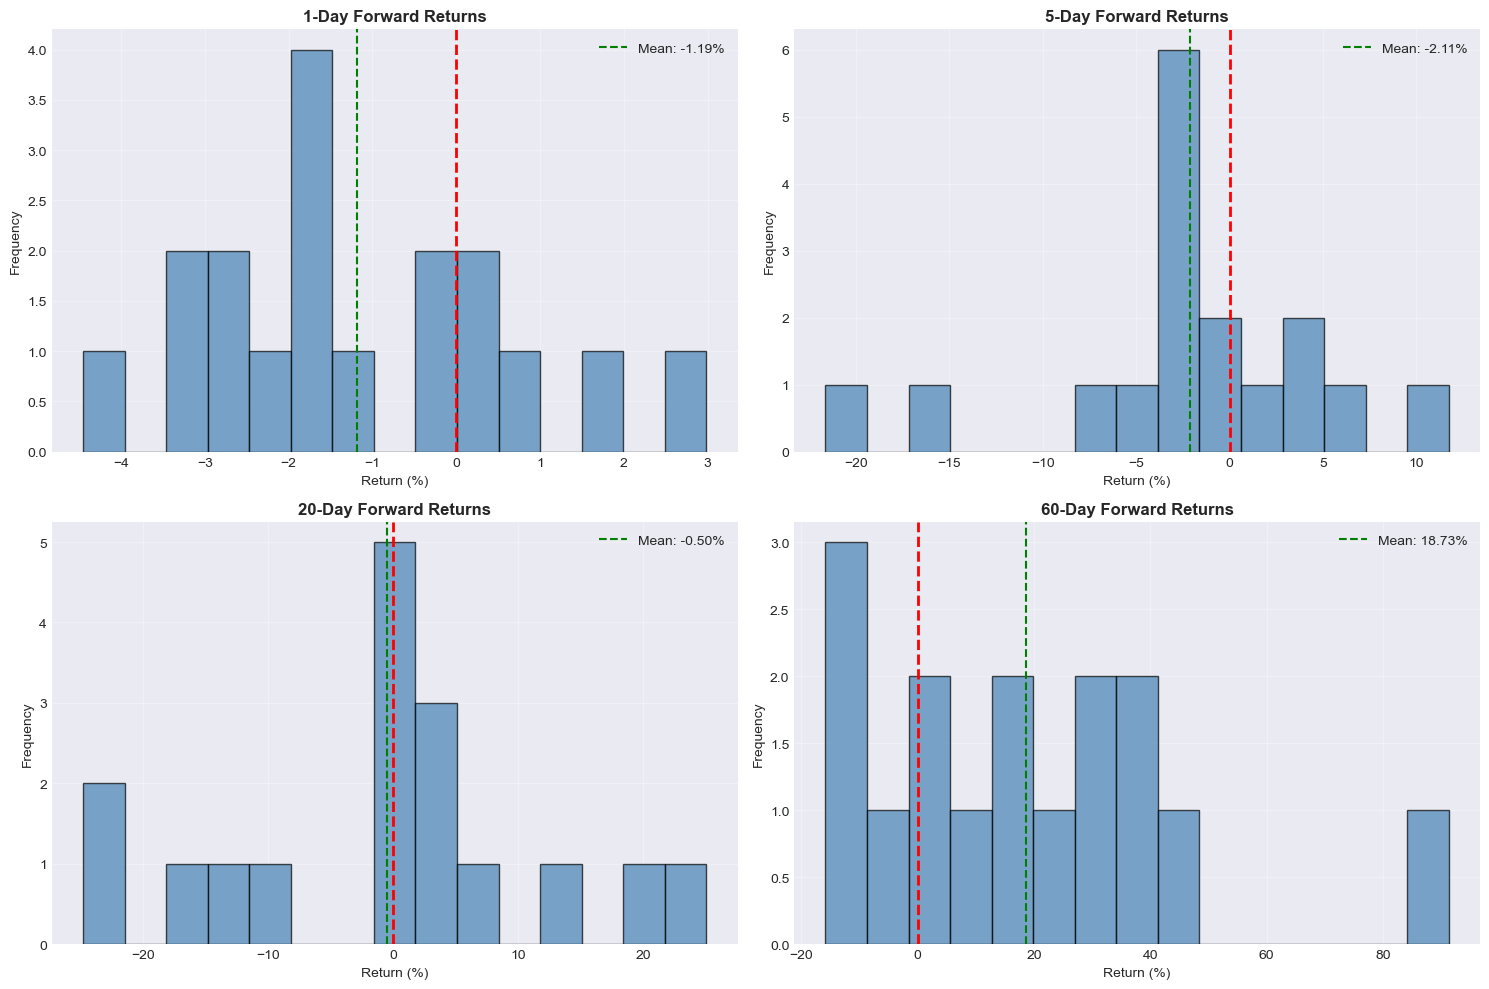

In [12]:
# Visualize forward returns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, period in enumerate(forward_periods):
    col = f'forward_return_{period}d'
    valid_data = purchases[col].dropna()
    
    if len(valid_data) > 0:
        axes[i].hist(valid_data, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].axvline(0, color='red', linestyle='--', linewidth=2)
        axes[i].axvline(valid_data.mean(), color='green', linestyle='--', 
                       label=f'Mean: {valid_data.mean():.2f}%')
        axes[i].set_title(f'{period}-Day Forward Returns', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Return (%)')
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [13]:
# Save enhanced trade data
output_file = '../data/pelosi_trades_clean.csv'
trade_data_enhanced.to_csv(output_file, index=False)
print(f"Saved enhanced trade data to: {output_file}")

# Save purchases with forward returns
purchases_file = '../data/pelosi_purchases_with_returns.csv'
purchases.to_csv(purchases_file, index=False)
print(f"Saved purchases with forward returns to: {purchases_file}")

# Save price data summary
price_summary = pd.DataFrame([
    {
        'ticker': ticker,
        'start_date': df.index.min(),
        'end_date': df.index.max(),
        'trading_days': len(df),
        'min_price': df['Close'].min(),
        'max_price': df['Close'].max(),
        'current_price': df['Close'].iloc[-1]
    }
    for ticker, df in price_data.items()
])

price_summary_file = '../data/price_data_summary.csv'
price_summary.to_csv(price_summary_file, index=False)
print(f"Saved price data summary to: {price_summary_file}")

print("\n" + "=" * 80)
print("DATA COLLECTION COMPLETE")
print("=" * 80)
print(f"\nTotal trades processed: {len(trade_data_enhanced)}")
print(f"Purchases: {len(purchases)}")
print(f"Sales: {len(trade_data_enhanced[trade_data_enhanced['transaction_type'] == 'Sale'])}")
print(f"Unique tickers: {len(price_data)}")
print("\nNext step: Proceed to 02_ExploratoryAnalysis.ipynb")

Saved enhanced trade data to: ../data/pelosi_trades_clean.csv
Saved purchases with forward returns to: ../data/pelosi_purchases_with_returns.csv
Saved price data summary to: ../data/price_data_summary.csv

DATA COLLECTION COMPLETE

Total trades processed: 20
Purchases: 18
Sales: 2
Unique tickers: 5

Next step: Proceed to 02_ExploratoryAnalysis.ipynb
